In [2]:
import os

print("Folders inside /kaggle/input/:")
print(os.listdir("/kaggle/input"))

Folders inside /kaggle/input/:
['datasets']


In [3]:
import glob

image_paths = glob.glob(
    "/kaggle/input/datasets/**/*.jpg",
    recursive=True
)

print("Number of JPG images:", len(image_paths))

print("\nFirst 10 images:")
for path in image_paths[:10]:
    print(path)

Number of JPG images: 20000

First 10 images:
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R06.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R09.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R07.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R02.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R03.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R08.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R00.jpg
/kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R04.jpg
/kaggle/input/datasets/sondosaabed/casia-i

Image path: /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/437/R/S5437R06.jpg
Image size: (640, 480)
Image mode: L


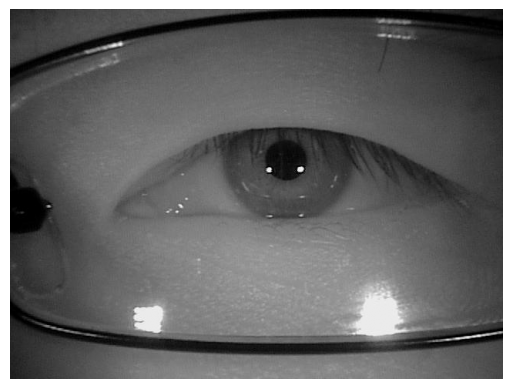

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

# Take the first image
image_path = image_paths[0]

# Open the image
img = Image.open(image_path)

print("Image path:", image_path)
print("Image size:", img.size)
print("Image mode:", img.mode)

# Display the image
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
from collections import Counter

# Extract the parts of the path
subjects = []
eyes = []

for path in image_paths:
    parts = path.split("/")
    
    # Find the subject number and eye folder
    subject = parts[-3]
    eye = parts[-2]
    
    subjects.append(subject)
    eyes.append(eye)

print("Number of unique subjects:", len(set(subjects)))
print("Subjects:", sorted(set(subjects))[:20])

print("\nEye types:", Counter(eyes))

Number of unique subjects: 1000
Subjects: ['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019']

Eye types: Counter({'R': 10000, 'L': 10000})


In [6]:
from collections import Counter

# Create an identity for each eye
eye_identities = []

for path in image_paths:
    parts = path.split("/")
    
    subject = parts[-3]
    eye = parts[-2]
    
    eye_id = f"{subject}-{eye}"
    eye_identities.append(eye_id)

# Count images belonging to each eye
images_per_eye = Counter(eye_identities)

print("Number of unique eye identities:", len(images_per_eye))

print("\nImages per eye:")
print(Counter(images_per_eye.values()))

Number of unique eye identities: 2000

Images per eye:
Counter({10: 2000})


In [7]:
import pandas as pd
import os

records = []

for path in image_paths:
    parts = path.split("/")
    
    subject = parts[-3]
    eye = parts[-2]
    filename = parts[-1]
    
    # Extract image number from filename
    # Example: S5437R06.jpg -> 06
    image_number = os.path.splitext(filename)[0][-2:]
    
    eye_id = f"{subject}-{eye}"
    
    records.append({
        "subject": subject,
        "eye": eye,
        "eye_id": eye_id,
        "image_number": image_number,
        "image_path": path
    })

# Create DataFrame
df = pd.DataFrame(records)

print("Dataset shape:", df.shape)

print("\nFirst 10 rows:")
display(df.head(10))

print("\nNumber of unique subjects:", df["subject"].nunique())
print("Number of unique eye identities:", df["eye_id"].nunique())

Dataset shape: (20000, 5)

First 10 rows:


,subject,eye,eye_id,image_number,image_path
0,437,R,437-R,06,/kaggle/input/datasets/sondosaabed/casia-iris-...
1,437,R,437-R,09,/kaggle/input/datasets/sondosaabed/casia-iris-...
2,437,R,437-R,07,/kaggle/input/datasets/sondosaabed/casia-iris-...
3,437,R,437-R,02,/kaggle/input/datasets/sondosaabed/casia-iris-...
4,437,R,437-R,03,/kaggle/input/datasets/sondosaabed/casia-iris-...
5,437,R,437-R,08,/kaggle/input/datasets/sondosaabed/casia-iris-...
6,437,R,437-R,00,/kaggle/input/datasets/sondosaabed/casia-iris-...
7,437,R,437-R,04,/kaggle/input/datasets/sondosaabed/casia-iris-...
8,437,R,437-R,01,/kaggle/input/datasets/sondosaabed/casia-iris-...
9,437,R,437-R,05,/kaggle/input/datasets/sondosaabed/casia-iris-...



Number of unique subjects: 1000
Number of unique eye identities: 2000


Eye identity: 437-R
Number of images: 10


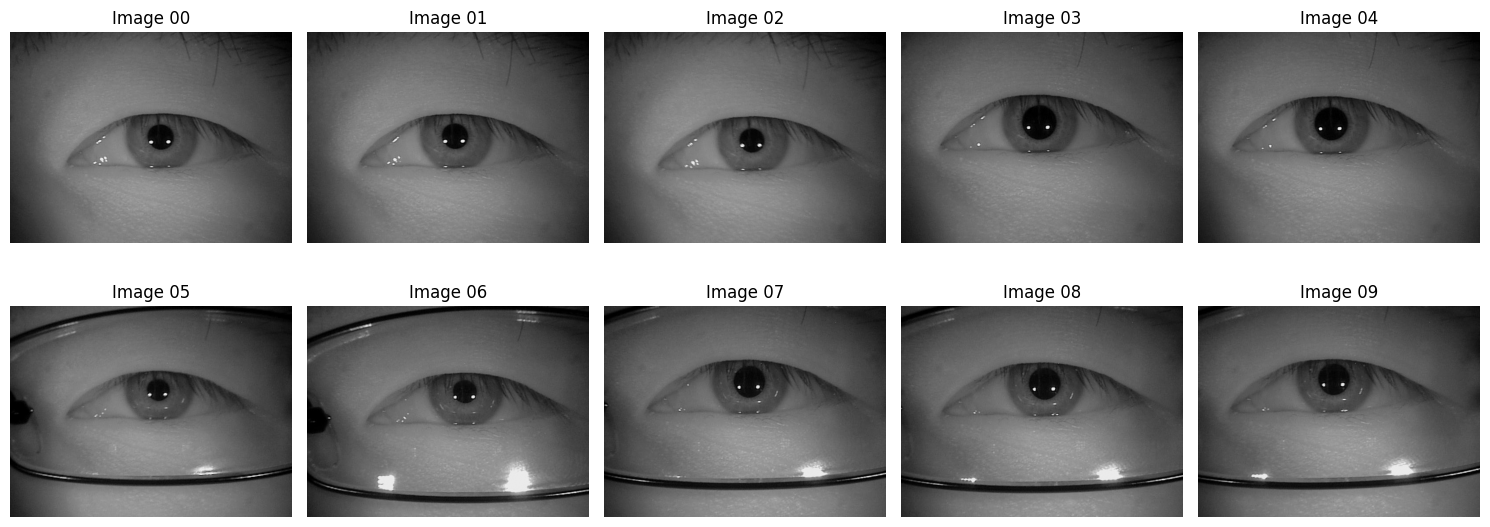

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

# Select one eye identity
sample_eye = "437-R"

# Get all images belonging to this eye
sample_df = df[df["eye_id"] == sample_eye].sort_values("image_number")

print("Eye identity:", sample_eye)
print("Number of images:", len(sample_df))

# Display all 10 images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for ax, (_, row) in zip(axes.ravel(), sample_df.iterrows()):
    img = Image.open(row["image_path"])
    
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Image {row['image_number']}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
import numpy as np
from PIL import Image

brightness_values = []
contrast_values = []
sizes = []

for path in image_paths:
    img = np.array(Image.open(path))
    
    brightness_values.append(img.mean())
    contrast_values.append(img.std())
    sizes.append(img.shape)

print("Number of images:", len(image_paths))

print("\nImage dimensions:")
print(Counter(sizes))

print("\nBrightness:")
print("Minimum:", min(brightness_values))
print("Maximum:", max(brightness_values))
print("Mean:", np.mean(brightness_values))

print("\nContrast (standard deviation):")
print("Minimum:", min(contrast_values))
print("Maximum:", max(contrast_values))
print("Mean:", np.mean(contrast_values))

Number of images: 20000

Image dimensions:
Counter({(480, 640): 20000})

Brightness:
Minimum: 62.903561197916666
Maximum: 212.81333658854166
Mean: 89.34454769042969

Contrast (standard deviation):
Minimum: 19.86592724791633
Maximum: 59.42500739543561
Mean: 32.51615103615219


In [11]:
from collections import Counter
import pandas as pd

# Count images for each subject
subject_counts = Counter(df["subject"])

print("Images per subject:")
print(Counter(subject_counts.values()))

print("\nNumber of subjects:", len(subject_counts))
print("Minimum images per subject:", min(subject_counts.values()))
print("Maximum images per subject:", max(subject_counts.values()))

# Count left and right eye images
print("\nImages by eye:")
print(df["eye"].value_counts())

# Count images for each eye identity
eye_counts = Counter(df["eye_id"])

print("\nImages per eye identity:")
print(Counter(eye_counts.values()))

print("\nNumber of eye identities:", len(eye_counts))
print("Minimum images per eye:", min(eye_counts.values()))
print("Maximum images per eye:", max(eye_counts.values()))

Images per subject:
Counter({20: 1000})

Number of subjects: 1000
Minimum images per subject: 20
Maximum images per subject: 20

Images by eye:
eye
R    10000
L    10000
Name: count, dtype: int64

Images per eye identity:
Counter({10: 2000})

Number of eye identities: 2000
Minimum images per eye: 10
Maximum images per eye: 10


In [12]:
from PIL import Image

# Check for duplicate paths
print("Total image paths:", len(image_paths))
print("Unique image paths:", len(set(image_paths)))

if len(image_paths) == len(set(image_paths)):
    print("✓ No duplicate image paths found")
else:
    print("⚠ Duplicate image paths found")


# Check whether every image can be opened
valid_images = 0
invalid_images = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            img.verify()
        valid_images += 1
    except Exception as e:
        invalid_images.append((path, str(e)))


print("\nValid images:", valid_images)
print("Invalid/corrupted images:", len(invalid_images))


# Display problematic files if any
if len(invalid_images) > 0:
    print("\nFirst 10 invalid files:")
    for path, error in invalid_images[:10]:
        print(path, "->", error)
else:
    print("✓ No corrupted/unreadable images found")

Total image paths: 20000
Unique image paths: 20000
✓ No duplicate image paths found

Valid images: 20000
Invalid/corrupted images: 0
✓ No corrupted/unreadable images found


Number of sampled images: 100
Number of pixels analyzed: 30720000
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 89.30374000651042
Standard deviation: 33.68714810687973


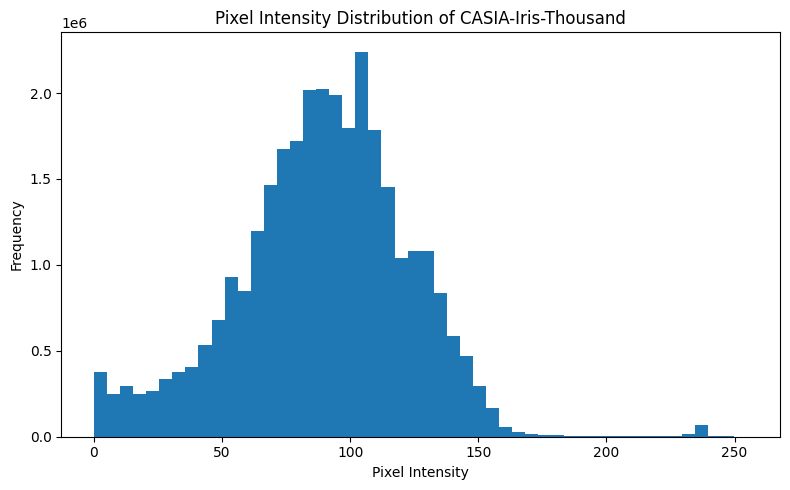

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Select a sample of images for analysis
sample_paths = image_paths[::200]   # approximately 100 images

pixel_values = []

for path in sample_paths:
    img = np.array(Image.open(path).convert("L"))
    pixel_values.extend(img.flatten())

pixel_values = np.array(pixel_values)

print("Number of sampled images:", len(sample_paths))
print("Number of pixels analyzed:", len(pixel_values))
print("Minimum pixel value:", pixel_values.min())
print("Maximum pixel value:", pixel_values.max())
print("Mean pixel value:", pixel_values.mean())
print("Standard deviation:", pixel_values.std())

# Plot pixel intensity distribution
plt.figure(figsize=(8, 5))

plt.hist(pixel_values, bins=50)

plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution of CASIA-Iris-Thousand")

plt.tight_layout()
plt.show()

In [14]:
# Check whether the dataset has balanced numbers of images
# across subjects and eyes

print("=== Dataset Balance Check ===")

subject_counts = df["subject"].value_counts()
eye_counts = df["eye_id"].value_counts()

print("\nImages per subject:")
print(subject_counts.describe())

print("\nImages per eye identity:")
print(eye_counts.describe())

print("\nSubjects with unexpected number of images:")
print(subject_counts[subject_counts != 20])

print("\nEye identities with unexpected number of images:")
print(eye_counts[eye_counts != 10])

=== Dataset Balance Check ===

Images per subject:
count    1000.0
mean       20.0
std         0.0
min        20.0
25%        20.0
50%        20.0
75%        20.0
max        20.0
Name: count, dtype: float64

Images per eye identity:
count    2000.0
mean       10.0
std         0.0
min        10.0
25%        10.0
50%        10.0
75%        10.0
max        10.0
Name: count, dtype: float64

Subjects with unexpected number of images:
Series([], Name: count, dtype: int64)

Eye identities with unexpected number of images:
Series([], Name: count, dtype: int64)


In [15]:
# Check the distribution of images between left and right eyes

print("=== Left vs Right Eye Distribution ===")

eye_distribution = df["eye"].value_counts()

print("\nImages by eye:")
print(eye_distribution)

print("\nPercentage by eye:")
print((eye_distribution / len(df) * 100).round(2))

=== Left vs Right Eye Distribution ===

Images by eye:
eye
R    10000
L    10000
Name: count, dtype: int64

Percentage by eye:
eye
R    50.0
L    50.0
Name: count, dtype: float64


In [16]:
# Check the distribution of image numbers (00-09)
# for each eye identity

print("=== Image Number Distribution ===")

image_number_distribution = df["image_number"].value_counts().sort_index()

print("\nImages by image number:")
print(image_number_distribution)

print("\nPercentage by image number:")
print((image_number_distribution / len(df) * 100).round(2))

=== Image Number Distribution ===

Images by image number:
image_number
00    2000
01    2000
02    2000
03    2000
04    2000
05    2000
06    2000
07    2000
08    2000
09    2000
Name: count, dtype: int64

Percentage by image number:
image_number
00    10.0
01    10.0
02    10.0
03    10.0
04    10.0
05    10.0
06    10.0
07    10.0
08    10.0
09    10.0
Name: count, dtype: float64


In [17]:
# Check whether image brightness differs between left and right eyes

print("=== Brightness by Eye ===")

brightness_by_eye = {}

for eye in ["L", "R"]:
    eye_paths = df[df["eye"] == eye]["image_path"]

    values = []

    for path in eye_paths:
        img = np.array(Image.open(path))
        values.append(img.mean())

    brightness_by_eye[eye] = values

print("\nLeft eye:")
print("Mean brightness:", np.mean(brightness_by_eye["L"]))
print("Std:", np.std(brightness_by_eye["L"]))

print("\nRight eye:")
print("Mean brightness:", np.mean(brightness_by_eye["R"]))
print("Std:", np.std(brightness_by_eye["R"]))

=== Brightness by Eye ===

Left eye:
Mean brightness: 89.64744930403646
Std: 4.972504702531135

Right eye:
Mean brightness: 89.04164607682291
Std: 3.640283143395602


In [18]:
# Check contrast characteristics between left and right eyes

print("=== Contrast by Eye ===")

contrast_by_eye = {}

for eye in ["L", "R"]:
    eye_paths = df[df["eye"] == eye]["image_path"]

    values = []

    for path in eye_paths:
        img = np.array(Image.open(path))
        values.append(img.std())

    contrast_by_eye[eye] = values

print("\nLeft eye:")
print("Mean contrast:", np.mean(contrast_by_eye["L"]))
print("Std:", np.std(contrast_by_eye["L"]))

print("\nRight eye:")
print("Mean contrast:", np.mean(contrast_by_eye["R"]))
print("Std:", np.std(contrast_by_eye["R"]))

=== Contrast by Eye ===

Left eye:
Mean contrast: 31.69894635323479
Std: 4.982829845225

Right eye:
Mean contrast: 33.33335571906958
Std: 4.778497628817492


In [20]:
# Check brightness variation across image numbers (00-09)

print("=== Brightness by Image Number ===")

brightness_by_number = {}

for number in sorted(df["image_number"].unique()):
    paths = df[df["image_number"] == number]["image_path"]

    values = []

    for path in paths:
        img = np.array(Image.open(path))
        values.append(img.mean())

    brightness_by_number[number] = values

print("\nMean brightness for each image number:")

for number, values in brightness_by_number.items():
    print(f"{number}: {np.mean(values):.2f}")

=== Brightness by Image Number ===

Mean brightness for each image number:
00: 90.16
01: 90.09
02: 90.05
03: 89.87
04: 89.64
05: 89.33
06: 88.90
07: 88.52
08: 88.48
09: 88.41


In [21]:
# Check brightness and contrast outliers

print("=== Brightness and Contrast Outlier Check ===")

brightness_array = np.array(brightness_values)
contrast_array = np.array(contrast_values)

# Calculate thresholds using mean ± 3 standard deviations
brightness_mean = np.mean(brightness_array)
brightness_std = np.std(brightness_array)

contrast_mean = np.mean(contrast_array)
contrast_std = np.std(contrast_array)

brightness_low = brightness_mean - 3 * brightness_std
brightness_high = brightness_mean + 3 * brightness_std

contrast_low = contrast_mean - 3 * contrast_std
contrast_high = contrast_mean + 3 * contrast_std

brightness_outliers = np.where(
    (brightness_array < brightness_low) |
    (brightness_array > brightness_high)
)[0]

contrast_outliers = np.where(
    (contrast_array < contrast_low) |
    (contrast_array > contrast_high)
)[0]

print("\nBrightness range:")
print("Lower threshold:", brightness_low)
print("Upper threshold:", brightness_high)
print("Number of brightness outliers:", len(brightness_outliers))

print("\nContrast range:")
print("Lower threshold:", contrast_low)
print("Upper threshold:", contrast_high)
print("Number of contrast outliers:", len(contrast_outliers))

=== Brightness and Contrast Outlier Check ===

Brightness range:
Lower threshold: 76.24018451623232
Upper threshold: 102.44891086462707
Number of brightness outliers: 179

Contrast range:
Lower threshold: 17.6671692767218
Upper threshold: 47.365132795582575
Number of contrast outliers: 148


In [22]:
# Identify the darkest and brightest images

print("=== Extreme Brightness Images ===")

darkest_indices = np.argsort(brightness_array)[:5]
brightest_indices = np.argsort(brightness_array)[-5:][::-1]

print("\n5 darkest images:")
for i in darkest_indices:
    print(f"Brightness: {brightness_array[i]:.2f} | {image_paths[i]}")

print("\n5 brightest images:")
for i in brightest_indices:
    print(f"Brightness: {brightness_array[i]:.2f} | {image_paths[i]}")

=== Extreme Brightness Images ===

5 darkest images:
Brightness: 62.90 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/527/L/S5527L09.jpg
Brightness: 68.21 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/245/R/S5245R00.jpg
Brightness: 69.50 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/291/L/S5291L08.jpg
Brightness: 70.09 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/290/L/S5290L09.jpg
Brightness: 71.03 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/006/L/S5006L08.jpg

5 brightest images:
Brightness: 212.81 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/035/L/S5035L01.jpg
Brightness: 201.96 | /kaggle/input/datasets/sondosaabed/casia-iris-thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/625/L

In [23]:
# ============================================
# FINAL DATASET QUALITY SUMMARY
# ============================================

print("============================================")
print("       CASIA-Iris-Thousand DATASET SUMMARY")
print("============================================")

print("\nDataset:")
print("Total images:", len(image_paths))
print("Total subjects:", df["subject"].nunique())
print("Total eye identities:", df["eye_id"].nunique())

print("\nImage distribution:")
print("Images per subject:", df.groupby("subject").size().unique())
print("Images per eye identity:", df.groupby("eye_id").size().unique())

print("\nEye distribution:")
print(df["eye"].value_counts())

print("\nImage dimensions:")
print(Counter(sizes))

print("\nImage quality:")
print(f"Mean brightness: {np.mean(brightness_values):.2f}")
print(f"Brightness range: {min(brightness_values):.2f} - {max(brightness_values):.2f}")
print(f"Mean contrast: {np.mean(contrast_values):.2f}")
print(f"Contrast range: {min(contrast_values):.2f} - {max(contrast_values):.2f}")

print("\nQuality issues:")
print("Corrupted/unreadable images: 0")
print("Duplicate image paths: 0")
print("Brightness outliers: 179")
print("Contrast outliers: 148")

print("\n============================================")
print("Dataset audit completed successfully.")
print("============================================")

       CASIA-Iris-Thousand DATASET SUMMARY

Dataset:
Total images: 20000
Total subjects: 1000
Total eye identities: 2000

Image distribution:
Images per subject: [20]
Images per eye identity: [10]

Eye distribution:
eye
R    10000
L    10000
Name: count, dtype: int64

Image dimensions:
Counter({(480, 640): 20000})

Image quality:
Mean brightness: 89.34
Brightness range: 62.90 - 212.81
Mean contrast: 32.52
Contrast range: 19.87 - 59.43

Quality issues:
Corrupted/unreadable images: 0
Duplicate image paths: 0
Brightness outliers: 179
Contrast outliers: 148

Dataset audit completed successfully.
